# Stacked CUT&RUN Heatmaps


In [1]:
import os, glob, gzip, json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

PROJECT_DIR = ".."
MATRIX_DIR  = os.path.join(PROJECT_DIR, "7_deeptools/matrices")
OUT_DIR     = os.path.join(PROJECT_DIR, "7_deeptools/stacked_heatmaps")
os.makedirs(OUT_DIR, exist_ok=True)

for f in sorted(glob.glob(os.path.join(MATRIX_DIR, "*.mat.gz"))):
    print(os.path.basename(f))

Fosb.cross_condition_consensus.tss.mat.gz
Fosb_GFP.tss.replicate.mat.gz
Fosb_TFF1.tss.replicate.mat.gz
H3K4me3.cross_condition_consensus.tss.mat.gz
H3K4me3_GFP.tss.replicate.mat.gz
H3K4me3_TFF1.tss.replicate.mat.gz
Junb.cross_condition_consensus.tss.mat.gz
Junb_GFP.tss.replicate.mat.gz
Junb_TFF1.tss.replicate.mat.gz


In [6]:
MATRIX_FILE = os.path.join(MATRIX_DIR, "H3K4me3.cross_condition_consensus.tss.mat.gz")  # <-- edit this

with gzip.open(MATRIX_FILE, "rt") as fh:
    header = json.loads(fh.readline().strip().lstrip("@"))
    rows = []
    for line in fh:
        fields = line.strip().split("\t")
        rows.append([float(v) if v != "nan" else np.nan for v in fields[6:]])

data = np.nan_to_num(np.array(rows), nan=0.0)

labels = header["sample_labels"]
bounds = header["sample_boundaries"]
n_bins = bounds[1] - bounds[0]
n_samples = len(labels)

sample_data = {}
for i, lab in enumerate(labels):
    sample_data[lab] = data[:, bounds[i]:bounds[i+1]]

up   = header["upstream"][0]
down = header["downstream"][0]
x_kb = np.linspace(-up / 1000, down / 1000, n_bins)

# Sort rows by first sample's mean signal (descending)
first = sample_data[labels[0]]
order = np.argsort(first.mean(axis=1))[::-1]
for lab in labels:
    sample_data[lab] = sample_data[lab][order]

# Shared color cap (99th percentile)
all_vals = np.concatenate([s.ravel() for s in sample_data.values()])
pos = all_vals[all_vals > 0]
vmax = np.percentile(pos, 99) if len(pos) > 0 else 5.0
n_peaks = first.shape[0]

print(f"Samples : {labels}")
print(f"Peaks   : {n_peaks:,}")
print(f"vmax    : {vmax:.4f}")

Samples : ['H3K4me3 GFP', 'H3K4me3 TFF1']
Peaks   : 105,269
vmax    : 4.4302


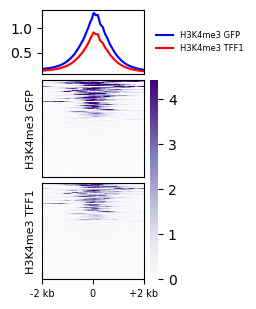

Saved: H3K4me3.cross_condition_consensus.tss.stacked.pdf


In [7]:
%matplotlib inline

# ── Settings (edit these) ────────────────────────────────────────────────
CMAP = "Purples"
#SAMPLE_COLORS = {labels[i]: c for i, c in enumerate(["Blue", "Red", "Green", "Orange"][:n_samples])}
SAMPLE_COLORS = {"H3K4me3 GFP": "Blue", "H3K4me3 TFF1": "Red"}

fig = plt.figure(figsize=(1.5, 3.5))
gs = gridspec.GridSpec(3, 2, height_ratios=[2, 3, 3],
                       width_ratios=[20, 1.5], hspace=0.07, wspace=0.12)

ax = fig.add_subplot(gs[0, 0])
for lab in labels:
    mu = sample_data[lab].mean(axis=0)
    se = sample_data[lab].std(axis=0) / np.sqrt(n_peaks)
    col = SAMPLE_COLORS[lab]
    ax.fill_between(x_kb, mu - se, mu + se, color=col, alpha=0.15)
    ax.plot(x_kb, mu, color=col, lw=1.5, label=lab)
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=6, frameon=False)
ax.set_xlim(x_kb[0], x_kb[-1])
ax.tick_params(axis="x", bottom=False, labelbottom=False)

kw = dict(aspect="auto", cmap=CMAP, vmin=0, vmax=vmax,
          extent=[x_kb[0], x_kb[-1], n_peaks, 0], interpolation="none")

for i, lab in enumerate(labels, start=1):
    ax = fig.add_subplot(gs[i, 0])
    im = ax.imshow(sample_data[lab], **kw)
    ax.set_ylabel(lab, fontsize=8)
    ax.tick_params(axis="y", left=False, labelleft=False)
    if i < n_samples:
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    else:
        ax.set_xticks([x_kb[0], 0, x_kb[-1]])
        ax.set_xticklabels([f"{x_kb[0]:.0f} kb", "0", f"+{x_kb[-1]:.0f} kb"], fontsize=7)

cbar = fig.colorbar(im, cax=fig.add_subplot(gs[1:, 1]))
cbar.outline.set_visible(False)

plt.show()

name = os.path.basename(MATRIX_FILE).replace(".mat.gz", "")
fig.savefig(os.path.join(OUT_DIR, f"{name}.stacked.pdf"), dpi=300, bbox_inches="tight")
print(f"Saved: {name}.stacked.pdf")